#Nastavení prostředí

In [ ]:
!git clone https://github.com/TomasFAV/InvoiceCzech.git /content/InvoiceCzech

Cloning into '/content/InvoiceCzech'...
remote: Enumerating objects: 467, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 467 (delta 33), reused 47 (delta 20), pack-reused 398 (from 1)
Receiving objects: 100% (467/467), 40.01 MiB | 10.40 MiB/s, done.
Resolving deltas: 100% (85/85), done.
Updating files: 100% (357/357), done.


In [ ]:
!pip install -q --upgrade transformers tokenizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 66.4 MB/s eta 0:00:00


In [ ]:
!pip install -q pytesseract

In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.5 MB/s eta 0:00:00


In [ ]:
!pip install zss

  Preparing metadata (setup.py) ... done
  Created wheel for zss: filename=zss-1.2.0-py3-none-any.whl size=6725 sha256=cc3185d83af96e1d818ec4422e1b9b2c5438af253bb0002c85efb4dcc3a007bd
  Stored in directory: /root/.cache/pip/wheels/46/e7/2e/44fb39352ad468427a7528cacbefefaa438a898dfd1ad2eaa4
Successfully built zss


In [ ]:
from zss import Node
import zss
from nltk import edit_distance

In [ ]:
import re
import json
import torch
from transformers import AutoProcessor, VisionEncoderDecoderConfig, AutoModel
from collections import Counter

In [ ]:
from tqdm.auto import tqdm
import torch
import json
from collections import Counter, defaultdict
from Levenshtein import distance as lev_distance

In [ ]:
DATASET_ID = "TomasFAV/RealDocumentInvoiceCzech"
MODEL_ID = "TomasFAV/DonutInvoiceCzechHUGGINGFACEV3"
device = "cuda" if torch.cuda.is_available() else "cpu"

#DATASET

In [ ]:
from datasets import load_dataset

val_dataset = load_dataset(DATASET_ID, split="train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39 [00:00<?, ? examples/s]

#MODEL


In [ ]:
from transformers import VisionEncoderDecoderModel

config = VisionEncoderDecoderConfig.from_pretrained(MODEL_ID)
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=True)
config.dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model = VisionEncoderDecoderModel.from_pretrained(MODEL_ID, config=config)
model.to(device)

config.json: 0.00B [00:00, ?B/s]

processor_config.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/806M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

VisionEncoderDecoderModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )

#METRIKY

In [ ]:
from InvoiceCzech.evaluation_utils.utils import *

# Evaluace

In [ ]:
import math

@torch.no_grad()
def evaluate(
    model,
    processor,
    dataset,
    device,
    max_length=512,
    limit=None,
    verbose=False,
    print_limit=None,
    only_mismatches=False,
    show_raw_generated_text=False
):
    model.eval()


    n = len(dataset)
    if limit is not None: n = min(n, limit)

    pbar = tqdm(range(n), desc="Evaluating Donut")

    ground_truths = list()
    predictions = list()

    for i in pbar:
        sample = dataset[i]

        # --- GT ---
        gt_raw = sample.get("ground_truth", None)
        gt_obj = json.loads(gt_raw) if isinstance(gt_raw, str) else gt_raw
        gt_json = gt_obj.get("gt_parse", gt_obj)

        # --- Predikce ---
        pixel_values = processor(sample["image"].convert("RGB"), return_tensors="pt").pixel_values
        pixel_values = pixel_values.to(device, dtype=model.dtype)
        #decoder_input_ids = processor.tokenizer("<s_cord-v2>", add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        generated_ids = model.generate(
                    pixel_values,
                    max_length=768,
                    early_stopping=True,
                    pad_token_id=processor.tokenizer.pad_token_id,
                    eos_token_id=processor.tokenizer.eos_token_id,
                    use_cache=True,
                    bad_words_ids=[[processor.tokenizer.unk_token_id]],
                    #return_dict_in_generate=True,
                )

        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

        pred_json = token2json(generated_text)

        ground_truths.append(gt_json)
        predictions.append(pred_json)


        metrics = compute_metrics(predictions, ground_truths)

        pbar.set_postfix(metrics)

    field_level = field_level_f1(predictions, ground_truths)
    plot_field_level_f1(field_level[0])

    return metrics


Evaluating Donut:   0%|          | 0/39 [00:00<?, ?it/s]

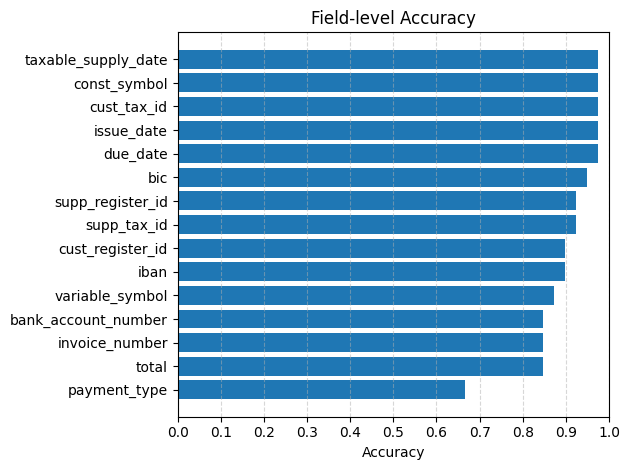

In [ ]:
evaluate(model, processor, val_dataset, device, verbose=True)